<a href="https://colab.research.google.com/github/inaianebarros/telecom-x/blob/main/telecom_x.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#<font color=blue size=7> Telecom X - Análise de Evasão de Clientes

# Objetivo
Você foi contratado como assistente de análise de dados na Telecom X e fará parte do projeto "Churn
de Clientes". A empresa enfrenta um alto índice de cancelamentos e precisa entender os fatores que
levam à perda de clientes.

Seu desafio será coletar, tratar e analisar os dados, utilizando Python e suas principais
bibliotecas para extrair insights valiosos. A partir da sua análise, os demais colegas da  equipe de
Data Science poderá avançar para modelos preditivos e desenvolver estratégias para reduzir a evasão.

O que você vai praticar:
- ✅ Importar e manipular dados de uma API de forma eficiente.
- ✅ Aplicar os conceitos de ETL (Extração, Transformação e Carga) na preparação dos dados.
- ✅ Criar visualizações de dados estratégicas para identificar padrões e tendências.
- ✅ Realizar uma Análise Exploratória de Dados (EDA) e gerar um relatório com insights relevantes.

# <font color=blue size=6> 1. Importação das bibliotecas

In [91]:
from pprint import pprint

import numpy as np
import pandas as pd
import seaborn as sns
import warnings
from matplotlib import pyplot as plt
from pandas import json_normalize
warnings.filterwarnings('ignore')


plt.style.use('default')
sns.set_palette("husl")
plt.rcParams['figure.figsize'] = (12, 8)

# <font color=blue size=6>2. Extração (E - Extract)

Para acessar os dados da API que fornece os dados em formato JSON, foi utilizado o método
`read_json` do pandas. A seguir o resultado da extração dos dados:

In [92]:
try:
    df = pd.read_json(
        'https://github.com/ingridcristh/challenge2-data-science/raw/main/TelecomX_Data.json'
        )
except Exception as exec:
    print('Erro ao tentar acessar dados da API')
    print(exec)
    raise exec

df.head()

,customerID,Churn,customer,phone,internet,account
0,0002-ORFBO,No,"{'gender': 'Female', 'SeniorCitizen': 0, 'Part...","{'PhoneService': 'Yes', 'MultipleLines': 'No'}","{'InternetService': 'DSL', 'OnlineSecurity': '...","{'Contract': 'One year', 'PaperlessBilling': '..."
1,0003-MKNFE,No,"{'gender': 'Male', 'SeniorCitizen': 0, 'Partne...","{'PhoneService': 'Yes', 'MultipleLines': 'Yes'}","{'InternetService': 'DSL', 'OnlineSecurity': '...","{'Contract': 'Month-to-month', 'PaperlessBilli..."
2,0004-TLHLJ,Yes,"{'gender': 'Male', 'SeniorCitizen': 0, 'Partne...","{'PhoneService': 'Yes', 'MultipleLines': 'No'}","{'InternetService': 'Fiber optic', 'OnlineSecu...","{'Contract': 'Month-to-month', 'PaperlessBilli..."
3,0011-IGKFF,Yes,"{'gender': 'Male', 'SeniorCitizen': 1, 'Partne...","{'PhoneService': 'Yes', 'MultipleLines': 'No'}","{'InternetService': 'Fiber optic', 'OnlineSecu...","{'Contract': 'Month-to-month', 'PaperlessBilli..."
4,0013-EXCHZ,Yes,"{'gender': 'Female', 'SeniorCitizen': 1, 'Part...","{'PhoneService': 'Yes', 'MultipleLines': 'No'}","{'InternetService': 'Fiber optic', 'OnlineSecu...","{'Contract': 'Month-to-month', 'PaperlessBilli..."


# <font color=blue size=6> 3. Transformação (T - Transform)

A transformação de dados é uma etapa crucial do processo ETL, pois garante que os dados estejam em um formato adequado para análise e tomada de decisões.

##1. Conhecendo o Dataset

Agora que você extraiu os dados, é fundamental entender a estrutura do dataset e o significado de suas colunas. Essa etapa ajudará a identificar quais variáveis são mais relevantes para a análise de evasão de clientes.

📌 Para te auxiliar nesse processo, criamos um dicionário de dados com a descrição de cada coluna. Embora não seja obrigatório utilizá-lo, ele pode facilitar a compreensão das informações disponíveis.

* `customerID`: número de identificação único de cada cliente
* `Churn`: se o cliente deixou ou não a empresa
* `gender`: gênero (masculino e feminino)
* `SeniorCitizen`: informação sobre um cliente ter ou não idade igual ou maior que 65 anos
* `Partner`:  se o cliente possui ou não um parceiro ou parceira
* `Dependents`: se o cliente possui ou não dependentes
* `tenure`:  meses de contrato do cliente
* `PhoneService`: assinatura de serviço telefônico
* `MultipleLines`: assisnatura de mais de uma linha de telefone
* `InternetService`: assinatura de um provedor internet
* `OnlineSecurity`: assinatura adicional de segurança online
* `OnlineBackup`: assinatura adicional de backup online
* `DeviceProtection`: assinatura adicional de proteção no dispositivo
* `TechSupport`: assinatura adicional de suporte técnico, menos tempo de espera
* `StreamingTV`: assinatura de TV a cabo
* `StreamingMovies`: assinatura de streaming de filmes
* `Contract`: tipo de contrato
* `PaperlessBilling`: se o cliente prefere receber online a fatura
* `PaymentMethod`: forma de pagamento
* `Charges.Monthly`: total de todos os serviços do cliente por mês
* `Charges.Total`: total gasto pelo cliente


#### O que você deve fazer:

1.   Explorar as colunas do dataset e verificar seus tipos de dados.
2.   Consultar o dicionário para entender melhor os significados das variáveis.
3.  Identificar as colunas mais relevantes para a análise de evasão.



### Identificar as colunas mais relevantes para a análise de evasão

👉 Como seu target é Churn (quem saiu ou não da empresa), as variáveis podem ser divididas em:

**Categóricas (nominais ou binárias)**

* `gender`
* `Partner`
* `Dependents`
* `PhoneService`
* `MultipleLines`
* `InternetService`
* `OnlineSecurity`
* `OnlineBackup`
* `DeviceProtection`
* `TechSupport`
* `StreamingTV`
* `StreamingMovies`
* `Contract`
* `PaperlessBilling`
* `PaymentMethod`

Essas ajudam a entender perfil e comportamento de serviço dos clientes.

**Numéricas**

* `SeniorCitizen (binária, mas numérica no dataset)`
* `tenure (tempo de contrato em meses)`
* `Charges.Monthly (custo mensal)`
* `Charges.Total (gasto total)`

Essas ajudam a entender nível de gasto e fidelidade.

**Chave de identificação**

* `customerID → não entra na análise (apenas identificador).`

**Variável-alvo**

* `Churn → target da análise/predição.`

In [93]:
df.head() #primeiras cinco linhas

,customerID,Churn,customer,phone,internet,account
0,0002-ORFBO,No,"{'gender': 'Female', 'SeniorCitizen': 0, 'Part...","{'PhoneService': 'Yes', 'MultipleLines': 'No'}","{'InternetService': 'DSL', 'OnlineSecurity': '...","{'Contract': 'One year', 'PaperlessBilling': '..."
1,0003-MKNFE,No,"{'gender': 'Male', 'SeniorCitizen': 0, 'Partne...","{'PhoneService': 'Yes', 'MultipleLines': 'Yes'}","{'InternetService': 'DSL', 'OnlineSecurity': '...","{'Contract': 'Month-to-month', 'PaperlessBilli..."
2,0004-TLHLJ,Yes,"{'gender': 'Male', 'SeniorCitizen': 0, 'Partne...","{'PhoneService': 'Yes', 'MultipleLines': 'No'}","{'InternetService': 'Fiber optic', 'OnlineSecu...","{'Contract': 'Month-to-month', 'PaperlessBilli..."
3,0011-IGKFF,Yes,"{'gender': 'Male', 'SeniorCitizen': 1, 'Partne...","{'PhoneService': 'Yes', 'MultipleLines': 'No'}","{'InternetService': 'Fiber optic', 'OnlineSecu...","{'Contract': 'Month-to-month', 'PaperlessBilli..."
4,0013-EXCHZ,Yes,"{'gender': 'Female', 'SeniorCitizen': 1, 'Part...","{'PhoneService': 'Yes', 'MultipleLines': 'No'}","{'InternetService': 'Fiber optic', 'OnlineSecu...","{'Contract': 'Month-to-month', 'PaperlessBilli..."


In [94]:
df.shape  # (linhas, colunas)

(7267, 6)

In [95]:
df.info() #tipos de dados

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7267 entries, 0 to 7266
Data columns (total 6 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   customerID  7267 non-null   object
 1   Churn       7267 non-null   object
 2   customer    7267 non-null   object
 3   phone       7267 non-null   object
 4   internet    7267 non-null   object
 5   account     7267 non-null   object
dtypes: object(6)
memory usage: 340.8+ KB


In [96]:
print(df.isnull().sum())  # valores nulos

customerID    0
Churn         0
customer      0
phone         0
internet      0
account       0
dtype: int64


In [97]:
#Foi possível observar que algumas colunas possuem dados aninhados, como pode ser observado na coluna "account".

df['account'][0]

{'Contract': 'One year',
 'PaperlessBilling': 'Yes',
 'PaymentMethod': 'Mailed check',
 'Charges': {'Monthly': 65.6, 'Total': '593.3'}}

## 2. Verificando Inconsistências nos Dados

Neste passo, verifique se há problemas nos dados que possam afetar a análise. Fique atento a valores ausentes, duplicados, erros de formatação e inconsistências nas categorias. Esse processo é essencial para garantir que os dados estejam prontos para as próximas etapas.



Para normalizar esses dados utilizaremos a função json_normalize().
A função json_normalize() é uma função do pandas que é usada para normalizar dados JSON aninhados.
Ela transforma um JSON aninhado em um DataFrame pandas, resultando em um dataframe com colunas
"expandidas" onde cada coluna é uma chave do JSON aninhado.

A seguir, o resultado da normalização:

In [98]:
df_normalized = json_normalize(df.to_dict('records'))
df_normalized.columns.to_list()

['customerID',
 'Churn',
 'customer.gender',
 'customer.SeniorCitizen',
 'customer.Partner',
 'customer.Dependents',
 'customer.tenure',
 'phone.PhoneService',
 'phone.MultipleLines',
 'internet.InternetService',
 'internet.OnlineSecurity',
 'internet.OnlineBackup',
 'internet.DeviceProtection',
 'internet.TechSupport',
 'internet.StreamingTV',
 'internet.StreamingMovies',
 'account.Contract',
 'account.PaperlessBilling',
 'account.PaymentMethod',
 'account.Charges.Monthly',
 'account.Charges.Total']

Agora, vamos explorar os dados de outras colunas do dataset

In [134]:
for column in df_normalized:
    if column not in [
        'customerID',
        'customer.tenure',
        'account.Charges.Monthly',
        'account.Charges.Total',
        'account.Charges.Daily',
    ]:
      print(f'{column}: {set(df_normalized[column])}')

Churn: {0, 1}
customer.gender: {'Female', 'Male'}
customer.SeniorCitizen: {0, 1}
customer.Partner: {0, 1}
customer.Dependents: {0, 1}
phone.PhoneService: {0, 1}
phone.MultipleLines: {0, 1}
internet.InternetService: {'No', 'Fiber optic', 'DSL'}
internet.OnlineSecurity: {0, 1}
internet.OnlineBackup: {0, 1}
internet.DeviceProtection: {0, 1}
internet.TechSupport: {0, 1}
internet.StreamingTV: {0, 1}
internet.StreamingMovies: {0, 1}
account.Contract: {'One year', 'Two year', 'Month-to-month'}
account.PaperlessBilling: {0, 1}
account.PaymentMethod: {'Credit card (automatic)', 'Electronic check', 'Mailed check', 'Bank transfer (automatic)'}


### Verificando os tipos de dados das Colunas

In [100]:
df_normalized.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7267 entries, 0 to 7266
Data columns (total 21 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   customerID                 7267 non-null   object 
 1   Churn                      7267 non-null   object 
 2   customer.gender            7267 non-null   object 
 3   customer.SeniorCitizen     7267 non-null   int64  
 4   customer.Partner           7267 non-null   object 
 5   customer.Dependents        7267 non-null   object 
 6   customer.tenure            7267 non-null   int64  
 7   phone.PhoneService         7267 non-null   object 
 8   phone.MultipleLines        7267 non-null   object 
 9   internet.InternetService   7267 non-null   object 
 10  internet.OnlineSecurity    7267 non-null   object 
 11  internet.OnlineBackup      7267 non-null   object 
 12  internet.DeviceProtection  7267 non-null   object 
 13  internet.TechSupport       7267 non-null   objec

É possivel perceber que a coluna "account.Charges.Total" é do tipo **object** quando na realidade deveriam ser **float64**.

In [101]:
df_normalized['account.Charges.Total'].dtypes

dtype('O')

### Verificando valores nulos e brancos

Verificando se há valores nulos na coluna account.Charges.Total

In [102]:
print(f'Total de valores nulos: {df_normalized["account.Charges.Total"].isnull().sum()}')

Total de valores nulos: 0


Verificando se há valores em brancos na coluna account.Charges.Total

In [103]:
print(f'Total de valores em branco: { len(df_normalized.loc[df_normalized["account.Charges.Total"] == " "])}')

Total de valores em branco: 11


Podemos verificar que existem 11 valores em branco na coluna, precisarem lidar com isto mais tarde, vamos continuar nossa análise de dados.



### Inconsistencia na categoria

Com uma breve análise, podemos ver que a coluna **Churn** possui os valores {'No', 'Yes', ' '}.

In [104]:
df_normalized['Churn'].value_counts()

,count
Churn,
No,5174
Yes,1869
,224


Analisando as colunas:

* `phone.MultipleLines`
* `internet.OnlineSecurity`
* `internet.OnlineBackup`
* `internet.DeviceProtection`
* `internet.TechSupport`
* `internet.StreamingTV`
* `internet.StreamingMovies`

É possível verificar que existem ocorrencias dos valores 'No phone service' e 'No internet service'.
Vamos verificar se esses casos na realidade representam 'No'.

In [105]:
columns_with_more_than_two_values = ['phone.MultipleLines',
'internet.OnlineSecurity',
'internet.OnlineBackup',
'internet.DeviceProtection',
'internet.TechSupport',
'internet.StreamingTV',
'internet.StreamingMovies',]

for column in columns_with_more_than_two_values:
  display(df_normalized[column].value_counts())

,count
phone.MultipleLines,
No,3495
Yes,3065
No phone service,707


,count
internet.OnlineSecurity,
No,3608
Yes,2078
No internet service,1581


,count
internet.OnlineBackup,
No,3182
Yes,2504
No internet service,1581


,count
internet.DeviceProtection,
No,3195
Yes,2491
No internet service,1581


,count
internet.TechSupport,
No,3582
Yes,2104
No internet service,1581


,count
internet.StreamingTV,
No,2896
Yes,2790
No internet service,1581


,count
internet.StreamingMovies,
No,2870
Yes,2816
No internet service,1581


É possível verificar que existem ocorrencias dos valores 'No phone service' e 'No internet service'.
Vamos verificar se esses casos na realidade representam 'No'.

## 3. Tratando as Inconsistências

Agora, com as inconsistências identificadas, é hora de aplicar as correções necessárias. Ajuste os dados para garantir que estejam completos e coerentes, preparando-os para as próximas etapas da análise.



### Conversão de dados e remoção de dados em branco.

Como a coluna **account.Charges.Total** não possui valores nulos, mas possui valores que são espaços em branco, vamos considerar esses valores '' como 0.

Após este processo podemos converter o dado do tipo **object** para **float**.


In [106]:
df_normalized['account.Charges.Total'] = (
    pd.to_numeric(df_normalized['account.Charges.Total'], errors='coerce').fillna(0)
)
print('Valores convertidos para float e espaços em branco considerados como 0.')
print(df_normalized.loc[df_normalized['account.Charges.Total'] == 0, 'account.Charges.Total'])

Valores convertidos para float e espaços em branco considerados como 0.
975     0.0
1775    0.0
1955    0.0
2075    0.0
2232    0.0
2308    0.0
2930    0.0
3134    0.0
3203    0.0
4169    0.0
5599    0.0
Name: account.Charges.Total, dtype: float64


In [107]:
print(f'Total de valores em branco: { len(df_normalized.loc[df_normalized["account.Charges.Total"] == " "])}')

Total de valores em branco: 0


### Ajustar inconsistencia nas categoria

Agora precimos analisar o valores '' de "Churn", para isso vamos verificar quantos % dos dados são
'' de "Churn".

In [108]:
df_normalized['Churn'].value_counts(normalize=True)

,proportion
Churn,
No,0.711986
Yes,0.257190
,0.030824


Como podemos observar os dados que possuem valor ' ' em **Churn** representam apenas ~3% do total de
dados, por isso, vamos remove-los do nosso dataset.

In [109]:
df_normalized = df_normalized[df_normalized['Churn'] != '']

In [110]:
df_normalized['Churn'].value_counts(normalize=True)

,proportion
Churn,
No,0.73463
Yes,0.26537


Com os valores deconhecidos removidos ficamos com apenas 97% de confiabilidade dos dados.

Vamos agora verificar se os valores **No phone service** e **No internet service** estão na verdade sendo as variáveis de **No**


```js
phone.MultipleLines: {'No', 'Yes', 'No phone service'}
internet.OnlineSecurity: {'No', 'Yes', 'No internet service'}
internet.OnlineBackup: {'No', 'Yes', 'No internet service'}
internet.DeviceProtection: {'No', 'Yes', 'No internet service'}
internet.TechSupport: {'No', 'Yes', 'No internet service'}
internet.StreamingTV: {'No', 'Yes', 'No internet service'}
internet.StreamingMovies: {'No', 'Yes', 'No internet service'}
```

In [111]:
def print_service_info(
    base_service: str,
    base_service_value: str,
    df: pd.DataFrame,
    extra_service: str,
    extra_service_value: str,
) -> None:
    _separators = "=" * 5
    print(f'{_separators} {extra_service} {_separators}')
    print(
        f'Numero de linhas que possuem o valor "{extra_service_value}" em {extra_service}: '
        f'{df[df[extra_service] == extra_service_value].shape[0]}'
    )

    print(
        f'Numero de linhas que possuem o valor "{base_service_value}" em {base_service}: '
        f'{df[df[base_service] == base_service_value].shape[0]}'
    )

    _ = (
        df[(df[base_service] == base_service_value)
        & (df[extra_service] != extra_service_value)].shape[0]
    )

    print(
        f'Numero de linhas que possuem o valor "{base_service_value}" em {base_service} e são '
        f'DIFERENTES de "{extra_service_value}" em {extra_service}: '
        f'{_}'
    )

    _ = df.loc[
        (df[extra_service] == extra_service_value) &
        (df[base_service] != base_service_value),
        'customerID'
    ]

    print(
        f'Numero de linhas que possuem o valor "{extra_service_value}" em {extra_service} e que não '
        f'fazem parte do conjunto que possui o valor "{base_service_value}" em {base_service}: '
        f'{_.shape[0]} \n\n'
    )

In [112]:
def normalize_value(column: str, df: pd.DataFrame, normalized_value: str, value: str) -> None:
    df.loc[
        df[column] == value, column
    ] = normalized_value
    print(f'{column}: {set(df[column])}')

In [113]:
print_service_info(
    'phone.PhoneService', 'No', df_normalized, 'phone.MultipleLines', 'No phone service'
)


===== phone.MultipleLines =====
Numero de linhas que possuem o valor "No phone service" em phone.MultipleLines: 682
Numero de linhas que possuem o valor "No" em phone.PhoneService: 682
Numero de linhas que possuem o valor "No" em phone.PhoneService e são DIFERENTES de "No phone service" em phone.MultipleLines: 0
Numero de linhas que possuem o valor "No phone service" em phone.MultipleLines e que não fazem parte do conjunto que possui o valor "No" em phone.PhoneService: 0 




Como foi observado, o número de linhas que possuem o valor "No phone service" em
"phone.MultipleLines" é igual ao número de linhas que possuem o valor "No" em "phone.PhoneService" e
o customerID é o mesmo para esses casos, dessa maneira, não precisamos utilizar o valor "No phone
service" em "phone.MultipleLines" para identificar os clientes que não possuem serviço de telefone,
basta utilizar "No". Vamos alterar os registros que possuem o valor "No phone service" em
"phone.MultipleLines" para "No".

In [114]:
normalize_value('phone.MultipleLines', df_normalized, 'No', 'No phone service')

phone.MultipleLines: {'Yes', 'No'}


Agora vamos fazer a mesma análise para os casos de "No internet service" em:
- internet.InternetService
- internet.OnlineSecurity
- internet.OnlineBackup
- internet.DeviceProtection
- internet.TechSupport
- internet.StreamingTV
- internet.StreamingMovies


In [115]:
base_service_value = 'No'

extra_service_value = 'No internet service'

internet_extra_services = [
    'internet.OnlineSecurity',
    'internet.OnlineBackup',
    'internet.DeviceProtection',
    'internet.TechSupport',
    'internet.StreamingTV',
    'internet.StreamingMovies',
]

base_service = 'internet.InternetService'
for extra_service in internet_extra_services[:3]:
    print_service_info(
        base_service, base_service_value, df_normalized, extra_service, extra_service_value
    )

===== internet.OnlineSecurity =====
Numero de linhas que possuem o valor "No internet service" em internet.OnlineSecurity: 1526
Numero de linhas que possuem o valor "No" em internet.InternetService: 1526
Numero de linhas que possuem o valor "No" em internet.InternetService e são DIFERENTES de "No internet service" em internet.OnlineSecurity: 0
Numero de linhas que possuem o valor "No internet service" em internet.OnlineSecurity e que não fazem parte do conjunto que possui o valor "No" em internet.InternetService: 0 


===== internet.OnlineBackup =====
Numero de linhas que possuem o valor "No internet service" em internet.OnlineBackup: 1526
Numero de linhas que possuem o valor "No" em internet.InternetService: 1526
Numero de linhas que possuem o valor "No" em internet.InternetService e são DIFERENTES de "No internet service" em internet.OnlineBackup: 0
Numero de linhas que possuem o valor "No internet service" em internet.OnlineBackup e que não fazem parte do conjunto que possui o valor

In [116]:
for extra_service in internet_extra_services[3:]:
    print_service_info(
        base_service, base_service_value, df_normalized, extra_service, extra_service_value
    )

===== internet.TechSupport =====
Numero de linhas que possuem o valor "No internet service" em internet.TechSupport: 1526
Numero de linhas que possuem o valor "No" em internet.InternetService: 1526
Numero de linhas que possuem o valor "No" em internet.InternetService e são DIFERENTES de "No internet service" em internet.TechSupport: 0
Numero de linhas que possuem o valor "No internet service" em internet.TechSupport e que não fazem parte do conjunto que possui o valor "No" em internet.InternetService: 0 


===== internet.StreamingTV =====
Numero de linhas que possuem o valor "No internet service" em internet.StreamingTV: 1526
Numero de linhas que possuem o valor "No" em internet.InternetService: 1526
Numero de linhas que possuem o valor "No" em internet.InternetService e são DIFERENTES de "No internet service" em internet.StreamingTV: 0
Numero de linhas que possuem o valor "No internet service" em internet.StreamingTV e que não fazem parte do conjunto que possui o valor "No" em interne

De acordo com os resultados, podemos tomar a mesma ação que foi tomada com o caso de
"phone.MultipleLines" e "phone.PhoneService" para todas as colunas de "internet.*"

In [117]:
for extra_service in internet_extra_services:
    normalize_value(extra_service, df_normalized, 'No', 'No internet service')

internet.OnlineSecurity: {'Yes', 'No'}
internet.OnlineBackup: {'Yes', 'No'}
internet.DeviceProtection: {'Yes', 'No'}
internet.TechSupport: {'Yes', 'No'}
internet.StreamingTV: {'Yes', 'No'}
internet.StreamingMovies: {'Yes', 'No'}


## 4. Coluna de Contas Diárias

Agora, com os dados limpos, é hora de criar a coluna "Contas_Diarias". Utilize o faturamento mensal para calcular o valor diário, proporcionando uma visão mais detalhada do comportamento dos clientes ao longo do tempo.

📌 Essa coluna ajudará a aprofundar sua análise e fornecer informações valiosas para as próximas etapas.

In [118]:
df_normalized['account.Charges.Daily'] = np.where(
    (df_normalized['customer.tenure'] > 0) & (df_normalized['account.Charges.Total'] > 0),
    (df_normalized['account.Charges.Total'] / (df_normalized['customer.tenure'] * 30)).round(2),
    0
)


## 5. Padronização e Transformação de Dados (Opcional)

A padronização e transformação de dados é uma etapa opcional, mas altamente recomendada, pois visa tornar as informações mais consistentes, compreensíveis e adequadas para análise. Durante essa fase, você pode, por exemplo, converter valores textuais como "Sim" e "Não" em valores binários (1 e 0), facilitando o processamento matemático e a aplicação de modelos analíticos.

In [119]:
binary_cols = [
    'Churn', 'customer.Partner', 'customer.Dependents',
    'phone.PhoneService', 'phone.MultipleLines',
    'internet.OnlineSecurity', 'internet.OnlineBackup',
    'internet.DeviceProtection', 'internet.TechSupport',
    'internet.StreamingTV', 'internet.StreamingMovies',
    'account.PaperlessBilling'
]

df_normalized[binary_cols] = df_normalized[binary_cols].replace({'Yes': 1, 'No': 0})


Agora temos o seguinte dataframe:

In [120]:
for column in df_normalized:
    print(f'{column}: {set(df_normalized[column])}')

customerID: {'3208-YPIOE', '7693-QPEFS', '9191-MYQKX', '5644-PDMZC', '0804-XBFBV', '9609-BENEA', '1894-IGFSG', '7080-TNUWP', '1169-SAOCL', '9548-LERKT', '9978-HYCIN', '6897-RWMUB', '0835-DUUIQ', '6339-TBELP', '9610-WCESF', '2690-DVRVK', '7853-OETYL', '5649-VUKMC', '2254-DLXRI', '2359-KMGLI', '3701-SFMUH', '8672-OAUPW', '5396-IZEPB', '0757-WCUUZ', '4753-PADAS', '9124-LHCJQ', '6583-QGCSI', '4328-VUFWD', '2782-LFZVW', '0754-EEBDC', '8065-BVEPF', '4625-LAMOB', '2682-KEVRP', '3276-HDUEG', '8083-YTZES', '9405-GPBBG', '6537-OTKMY', '8775-ERLNB', '4789-KWMXN', '1752-OZXFY', '0480-BIXDE', '7139-JZFVG', '5701-SVCWR', '9522-ZSINC', '0125-LZQXK', '4662-EKDPQ', '4609-KNNWG', '6683-VLCTZ', '2665-NPTGL', '8232-CTLKO', '2581-VKIRT', '0568-ONFPC', '7912-SYRQT', '7298-IZWLY', '8180-AKMJV', '2911-IJORQ', '9281-OFDMF', '3398-GCPMU', '0924-BJCRC', '6976-BWGLQ', '4983-CLMLV', '1810-BOHSY', '9170-GYZJC', '1450-GALXR', '3002-WQZWT', '5537-UXXVS', '1051-GEJLJ', '8775-CEBBJ', '1905-OEILC', '4654-GGUII', '3663-M

# <font color=blue size=6> 4. Carga e Análise (L - Load & Analysis)

## 1. Análise Descritiva

In [121]:
# Informações básicas do dataset
print(f"Dimensões do dataset: {df_normalized.shape}")
print("\nTipos de dados:")
print(df_normalized.dtypes)
df_normalized.head()

Dimensões do dataset: (7043, 22)

Tipos de dados:
customerID                    object
Churn                          int64
customer.gender               object
customer.SeniorCitizen         int64
customer.Partner               int64
customer.Dependents            int64
customer.tenure                int64
phone.PhoneService             int64
phone.MultipleLines            int64
internet.InternetService      object
internet.OnlineSecurity        int64
internet.OnlineBackup          int64
internet.DeviceProtection      int64
internet.TechSupport           int64
internet.StreamingTV           int64
internet.StreamingMovies       int64
account.Contract              object
account.PaperlessBilling       int64
account.PaymentMethod         object
account.Charges.Monthly      float64
account.Charges.Total        float64
account.Charges.Daily        float64
dtype: object


,customerID,Churn,customer.gender,customer.SeniorCitizen,customer.Partner,customer.Dependents,customer.tenure,phone.PhoneService,phone.MultipleLines,internet.InternetService,...,internet.DeviceProtection,internet.TechSupport,internet.StreamingTV,internet.StreamingMovies,account.Contract,account.PaperlessBilling,account.PaymentMethod,account.Charges.Monthly,account.Charges.Total,account.Charges.Daily
0,0002-ORFBO,0,Female,0,1,1,9,1,0,DSL,...,0,1,1,0,One year,1,Mailed check,65.6,593.30,2.20
1,0003-MKNFE,0,Male,0,0,0,9,1,1,DSL,...,0,0,0,1,Month-to-month,0,Mailed check,59.9,542.40,2.01
2,0004-TLHLJ,1,Male,0,0,0,4,1,0,Fiber optic,...,1,0,0,0,Month-to-month,1,Electronic check,73.9,280.85,2.34
3,0011-IGKFF,1,Male,1,1,0,13,1,0,Fiber optic,...,1,0,1,1,Month-to-month,1,Electronic check,98.0,1237.85,3.17
4,0013-EXCHZ,1,Female,1,1,0,3,1,0,Fiber optic,...,0,1,1,0,Month-to-month,1,Mailed check,83.9,267.40,2.97


In [122]:
# Identificar colunas numéricas
numeric_cols = ['customer.tenure', 'account.Charges.Monthly', 'account.Charges.Total', 'account.Charges.Daily']

# Estatísticas descritivas completas
descriptive_stats = df_normalized[numeric_cols].describe()
descriptive_stats.loc['variance'] = df_normalized[numeric_cols].var()
descriptive_stats.loc['skewness'] = df_normalized[numeric_cols].skew()
descriptive_stats.loc['kurtosis'] = df_normalized[numeric_cols].kurtosis()

descriptive_stats.round(2)

,customer.tenure,account.Charges.Monthly,account.Charges.Total,account.Charges.Daily
count,7043.00,7043.00,7043.00,7043.00
mean,32.37,64.76,2279.73,2.16
std,24.56,30.09,2266.79,1.01
min,0.00,18.25,0.00,0.00
25%,9.00,35.50,398.55,1.19
50%,29.00,70.35,1394.55,2.34
75%,55.00,89.85,3786.60,3.01
max,72.00,118.75,8684.80,4.05
variance,603.17,905.41,5138357.17,1.02
skewness,0.24,-0.22,0.96,-0.21


In [123]:
# Análise da distribuição de Churn
churn_distribution = df_normalized['Churn'].value_counts()
churn_percentage = df_normalized['Churn'].value_counts(normalize=True) * 100

# Criar DataFrame para visualização
churn_summary = pd.DataFrame({
    'Contagem': churn_distribution,
    'Percentual': churn_percentage.round(2)
})
churn_summary.index = ['Não Evadiu', 'Evadiu']
churn_summary

,Contagem,Percentual
Não Evadiu,5174,73.46
Evadiu,1869,26.54


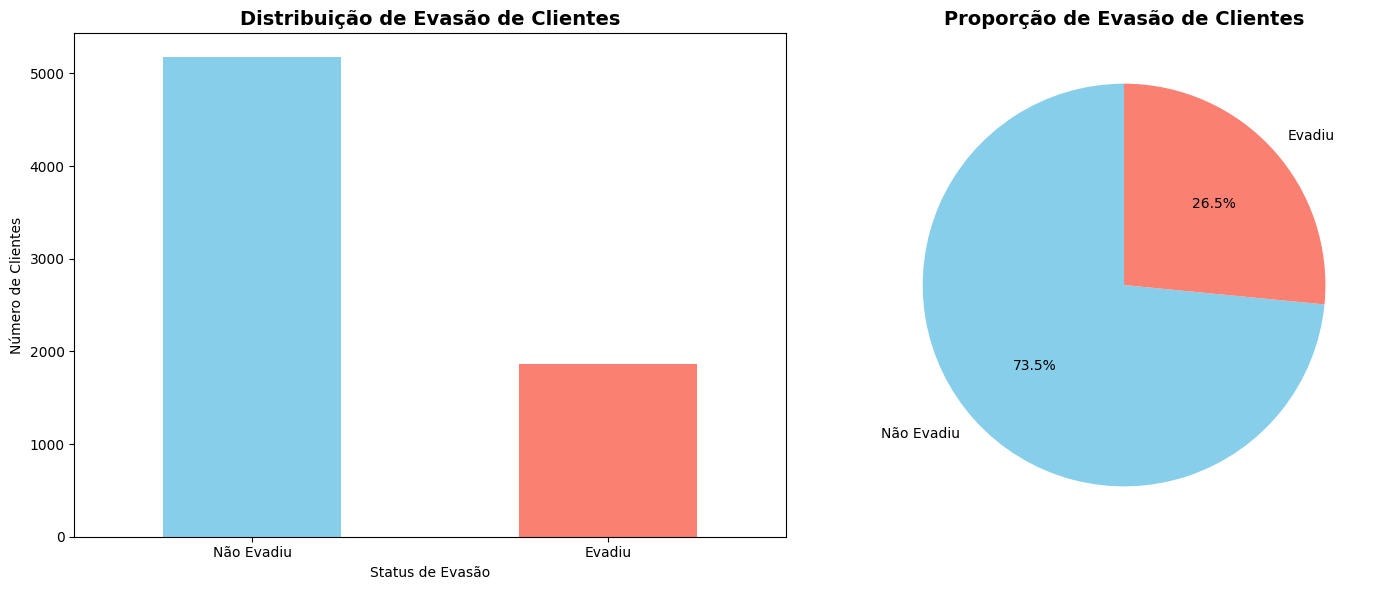

In [124]:
# Visualização da distribuição de Churn
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))

# Gráfico de barras
churn_summary['Contagem'].plot(kind='bar', ax=ax1, color=['skyblue', 'salmon'])
ax1.set_title('Distribuição de Evasão de Clientes', fontsize=14, fontweight='bold')
ax1.set_xlabel('Status de Evasão')
ax1.set_ylabel('Número de Clientes')
ax1.tick_params(axis='x', rotation=0)

# Gráfico de pizza
ax2.pie(churn_summary['Contagem'], labels=churn_summary.index, autopct='%1.1f%%',
        colors=['skyblue', 'salmon'], startangle=90)
ax2.set_title('Proporção de Evasão de Clientes', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.show()

In [125]:
# Identificar variáveis categóricas
categorical_cols = ['customer.gender', 'customer.SeniorCitizen', 'customer.Partner',
                   'customer.Dependents', 'phone.PhoneService', 'phone.MultipleLines',
                   'internet.InternetService', 'internet.OnlineSecurity', 'internet.OnlineBackup',
                   'internet.DeviceProtection', 'internet.TechSupport', 'internet.StreamingTV',
                   'internet.StreamingMovies', 'account.Contract', 'account.PaperlessBilling',
                   'account.PaymentMethod']

# Função para análise de variáveis categóricas
def analyze_categorical_variable(df, column):
    freq_table = df[column].value_counts()
    prop_table = df[column].value_counts(normalize=True) * 100

    result_df = pd.DataFrame({
        'Frequência': freq_table,
        'Percentual': prop_table.round(2)
    })

    return result_df

# Análise de cada variável categórica
for col in categorical_cols:  # Primeiras 5 para exemplo
    print(f"\n=== Análise de {col} ===")
    display(analyze_categorical_variable(df_normalized, col))


=== Análise de customer.gender ===


,Frequência,Percentual
customer.gender,,
Male,3555,50.48
Female,3488,49.52



=== Análise de customer.SeniorCitizen ===


,Frequência,Percentual
customer.SeniorCitizen,,
0,5901,83.79
1,1142,16.21



=== Análise de customer.Partner ===


...

,Frequência,Percentual
account.Contract,,
Month-to-month,3875,55.02
Two year,1695,24.07
One year,1473,20.91



=== Análise de account.PaperlessBilling ===


,Frequência,Percentual
account.PaperlessBilling,,
1,4171,59.22
0,2872,40.78



=== Análise de account.PaymentMethod ===


,Frequência,Percentual
account.PaymentMethod,,
Electronic check,2365,33.58
Mailed check,1612,22.89
Bank transfer (automatic),1544,21.92
Credit card (automatic),1522,21.61


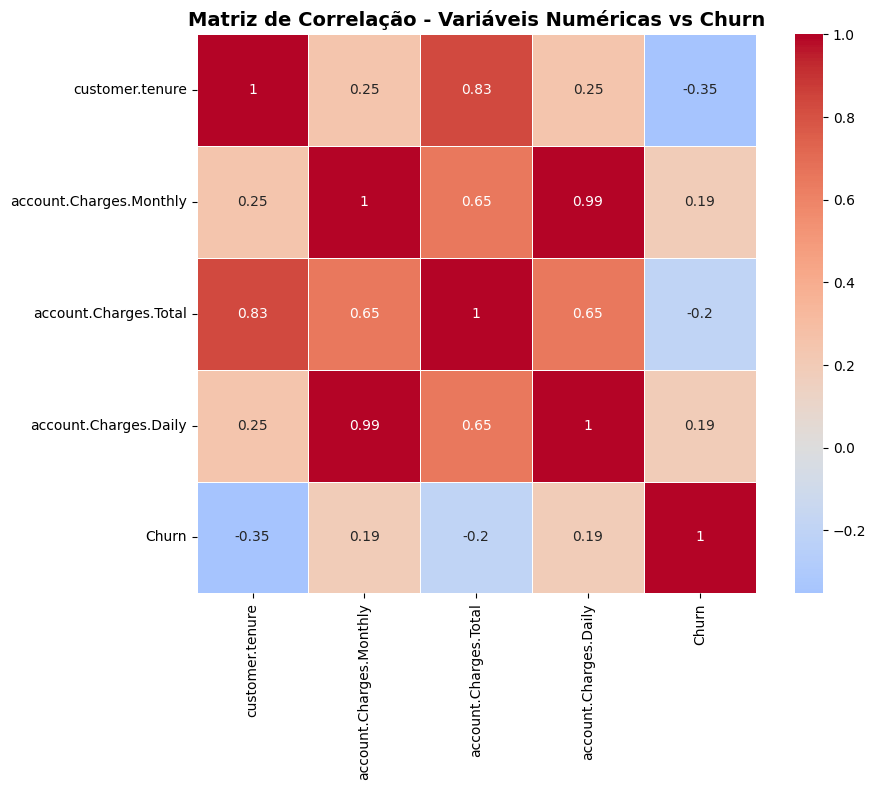

In [126]:
# Matriz de correlação
correlation_matrix = df_normalized[numeric_cols + ['Churn']].corr()

# Visualização da matriz de correlação
plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', center=0,
            square=True, linewidths=0.5)
plt.title('Matriz de Correlação - Variáveis Numéricas vs Churn',
          fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

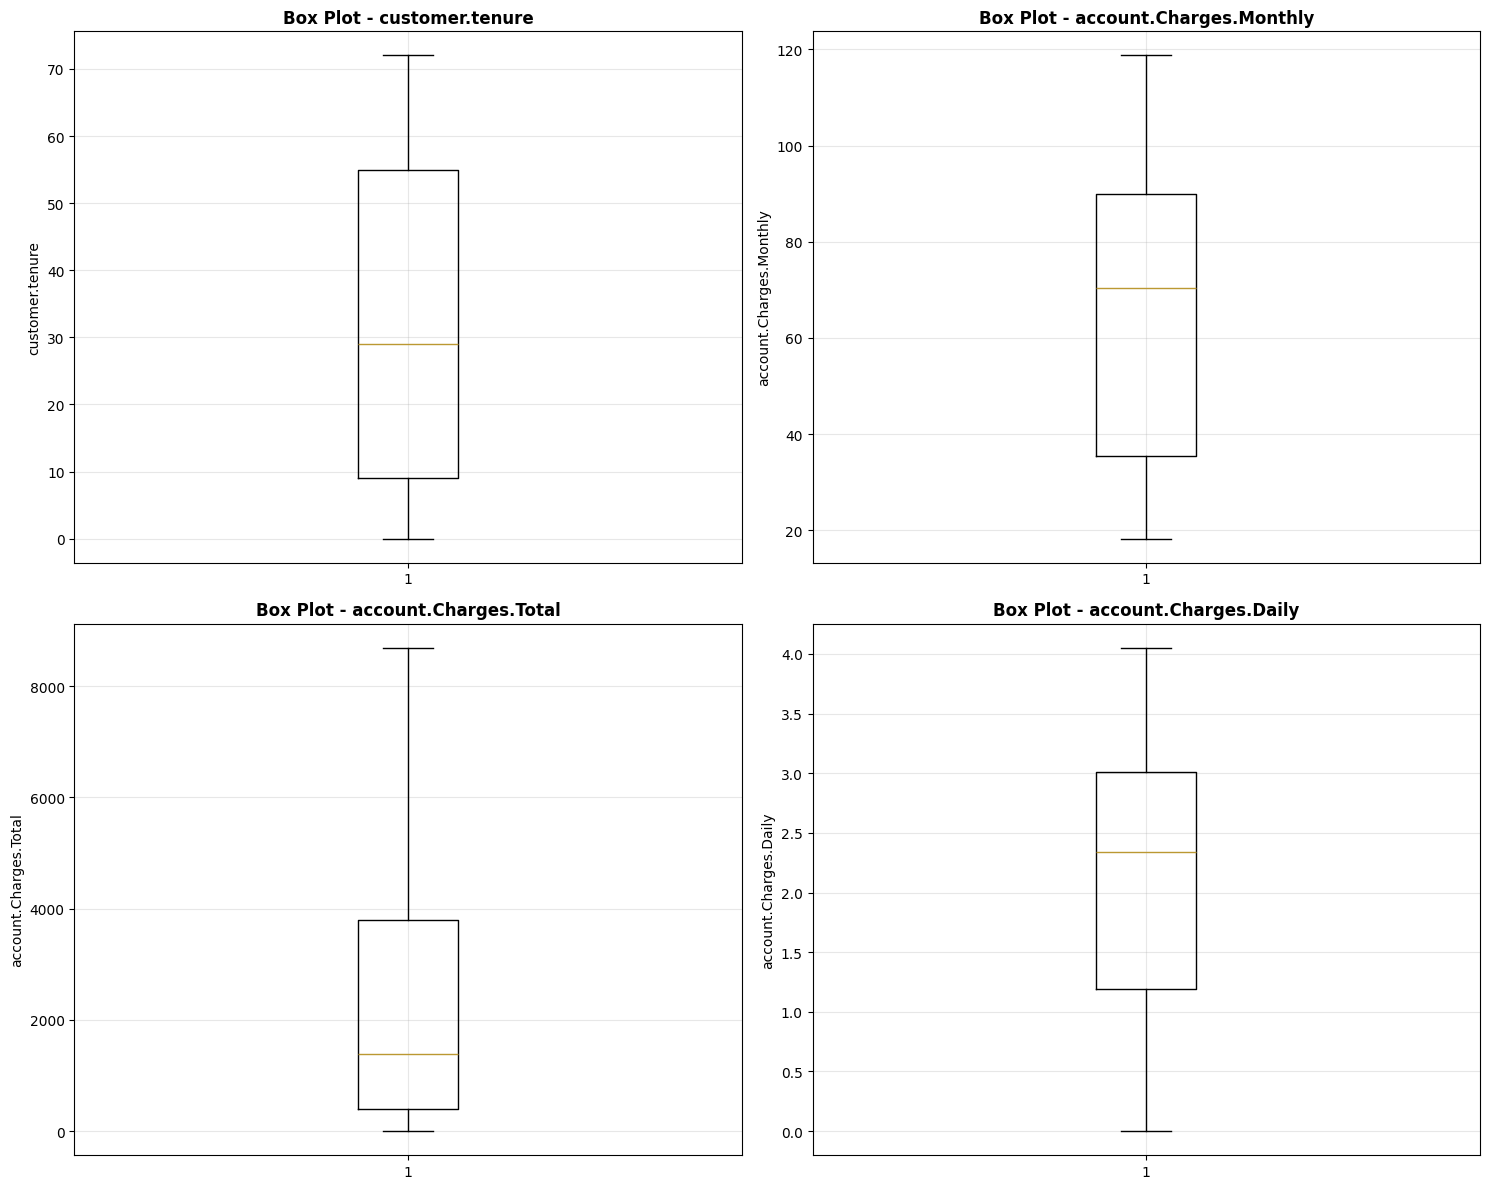

In [127]:
# Box plots das variáveis numéricas
fig, axes = plt.subplots(2, 2, figsize=(15, 12))
axes = axes.ravel()

for i, col in enumerate(numeric_cols):
    axes[i].boxplot(df_normalized[col])
    axes[i].set_title(f'Box Plot - {col}', fontweight='bold')
    axes[i].set_ylabel(col)
    axes[i].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [128]:
# Comparação das médias por grupo de Churn
churn_comparison = df_normalized.groupby('Churn')[numeric_cols].agg(['mean', 'median', 'std']).round(2)
churn_comparison

customer.tenure               account.Charges.Monthly                \
                 mean median    std                    mean median    std   
Churn                                                                       
0               37.57   38.0  24.11                   61.27  64.43  31.09   
1               17.98   10.0  19.53                   74.44  79.65  24.67   

      account.Charges.Total                   account.Charges.Daily         \
                       mean   median      std                  mean median   
Churn                                                                        
0                   2549.91  1679.52  2329.95                  2.04   2.13   
1                   1531.80   703.55  1890.82                  2.48   2.64   

             
        std  
Churn        
0      1.04  
1      0.83

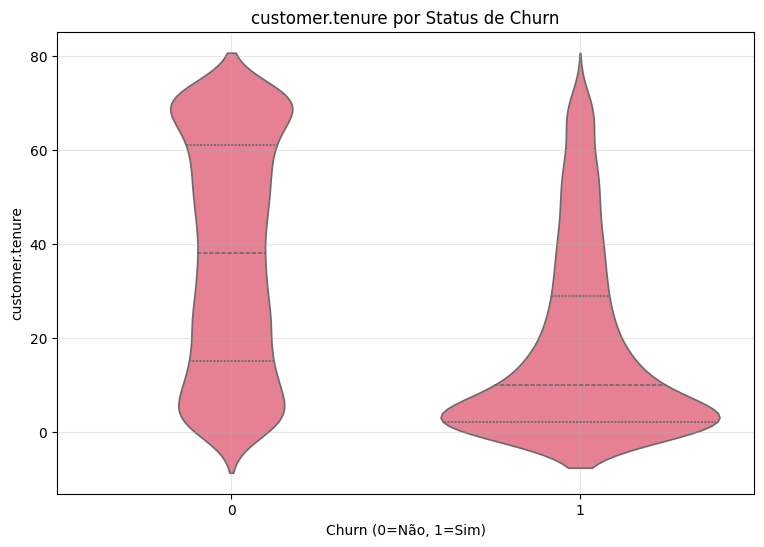

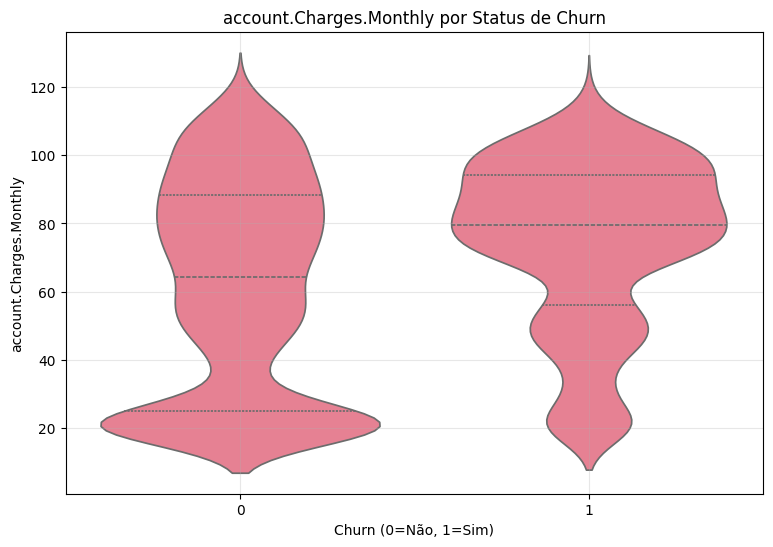

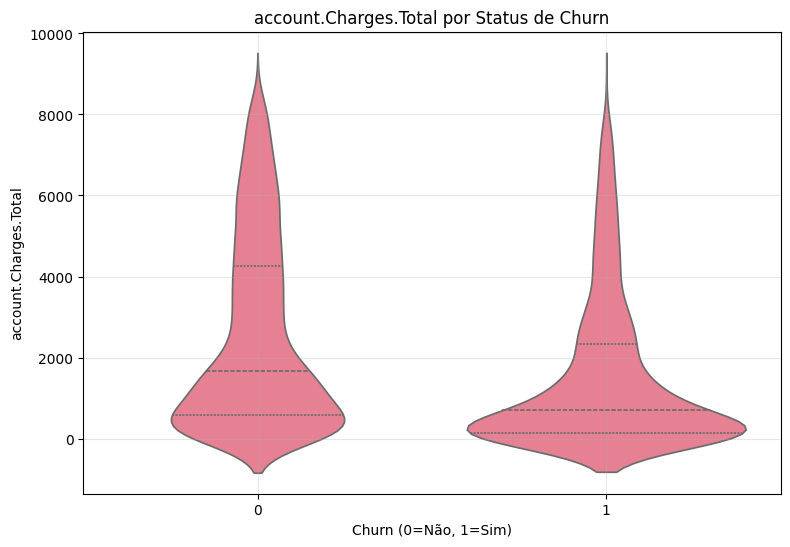

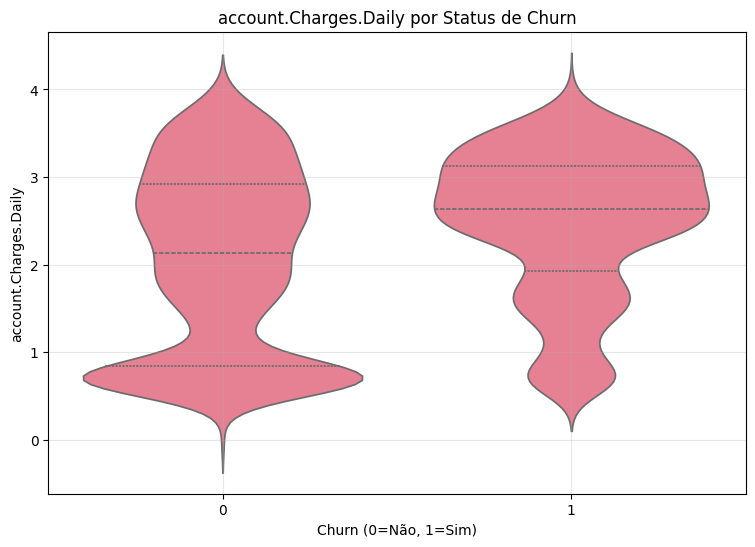

In [129]:
import seaborn as sns

for col in numeric_cols:
    plt.figure(figsize=(9, 6))
    sns.violinplot(x='Churn', y=col, data=df_normalized, inner='quartile')
    plt.title(f'{col} por Status de Churn')
    plt.xlabel('Churn (0=Não, 1=Sim)')
    plt.ylabel(col)
    plt.grid(True, alpha=0.3)
    plt.show()


In [130]:
# Função para criar tabelas de contingência
def contingency_analysis(df, categorical_var, target='Churn'):
    # Tabela de contingência
    contingency_table = pd.crosstab(df[categorical_var], df[target], margins=True)

    # Percentuais por linha
    percentage_table = pd.crosstab(df[categorical_var], df[target], normalize='index') * 100

    print(f"\n=== Tabela de Contingência: {categorical_var} vs {target} ===")
    print("\nContagens:")
    display(contingency_table)

    print("\nPercentuais por linha:")
    display(percentage_table.round(2))

    return contingency_table, percentage_table

# Exemplo para algumas variáveis categóricas importantes
for col in ['customer.gender', 'customer.SeniorCitizen', 'account.Contract']:
    contingency_analysis(df_normalized, col)


=== Tabela de Contingência: customer.gender vs Churn ===

Contagens:


Churn,0,1,All
customer.gender,,,
Female,2549,939,3488
Male,2625,930,3555
All,5174,1869,7043



Percentuais por linha:


Churn,0,1
customer.gender,,
Female,73.08,26.92
Male,73.84,26.16



=== Tabela de Contingência: customer.SeniorCitizen vs Churn ===

Contagens:


...

Churn,0,1
customer.SeniorCitizen,,
0,76.39,23.61
1,58.32,41.68



=== Tabela de Contingência: account.Contract vs Churn ===

Contagens:


Churn,0,1,All
account.Contract,,,
Month-to-month,2220,1655,3875
One year,1307,166,1473
Two year,1647,48,1695
All,5174,1869,7043



Percentuais por linha:


Churn,0,1
account.Contract,,
Month-to-month,57.29,42.71
One year,88.73,11.27
Two year,97.17,2.83


In [131]:
# Resumo executivo das principais métricas
print("=== RESUMO EXECUTIVO DA ANÁLISE DESCRITIVA ===")
print("\n📊 Informações Gerais:")
print(f"   • Total de clientes: {len(df_normalized):,}")
print(f"   • Taxa de evasão: {(df_normalized['Churn'].mean() * 100):.2f}%")
print(f"   • Clientes que evadiram: {df_normalized['Churn'].sum():,}")
print(f"   • Clientes ativos: {(len(df_normalized) - df_normalized['Churn'].sum()):,}")

print("\n💰 Métricas Financeiras:")
print(f"   • Receita mensal média: R$ {df_normalized['account.Charges.Monthly'].mean():.2f}")
print(f"   • Receita total média por cliente: R$ {df_normalized['account.Charges.Total'].mean():.2f}")
print(f"   • Tempo médio de contrato: {df_normalized['customer.tenure'].mean():.1f} meses")

print("\n📈 Variabilidade dos Dados:")
for col in numeric_cols:
    cv = (df_normalized[col].std() / df_normalized[col].mean()) * 100
    print(f"   • Coeficiente de variação {col}: {cv:.2f}%")

=== RESUMO EXECUTIVO DA ANÁLISE DESCRITIVA ===

📊 Informações Gerais:
   • Total de clientes: 7,043
   • Taxa de evasão: 26.54%
   • Clientes que evadiram: 1,869
   • Clientes ativos: 5,174

💰 Métricas Financeiras:
   • Receita mensal média: R$ 64.76
   • Receita total média por cliente: R$ 2279.73
   • Tempo médio de contrato: 32.4 meses

📈 Variabilidade dos Dados:
   • Coeficiente de variação customer.tenure: 75.87%
   • Coeficiente de variação account.Charges.Monthly: 46.46%
   • Coeficiente de variação account.Charges.Total: 99.43%
   • Coeficiente de variação account.Charges.Daily: 46.79%
